In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

from math import sqrt
from sklearn.metrics import mean_squared_error

In [6]:
df = pd.read_csv('AirPassengers.csv',parse_dates=['Month'],index_col='Month')

In [7]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


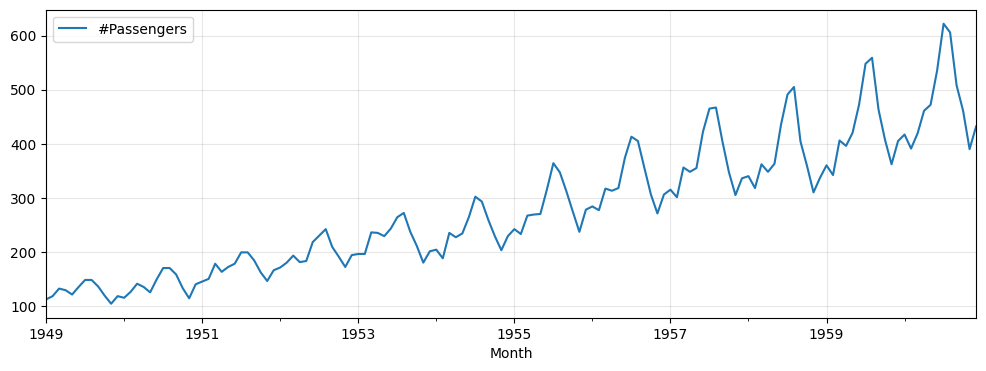

In [10]:
df.plot()
plt.show()

In [11]:
# I think this is a multiplicative time series ; moving on to decomposing each part and plotting them one by one for better understanding 

In [15]:
decomposed_df = seasonal_decompose(df['#Passengers'],model="multiplicative")

In [17]:
# we can even use the plot function directly here on the decomposed_df and set the size in inches by fetching the current figure but we will skip that for now and focus 
# on decomposing each of the time series element and moving forward 

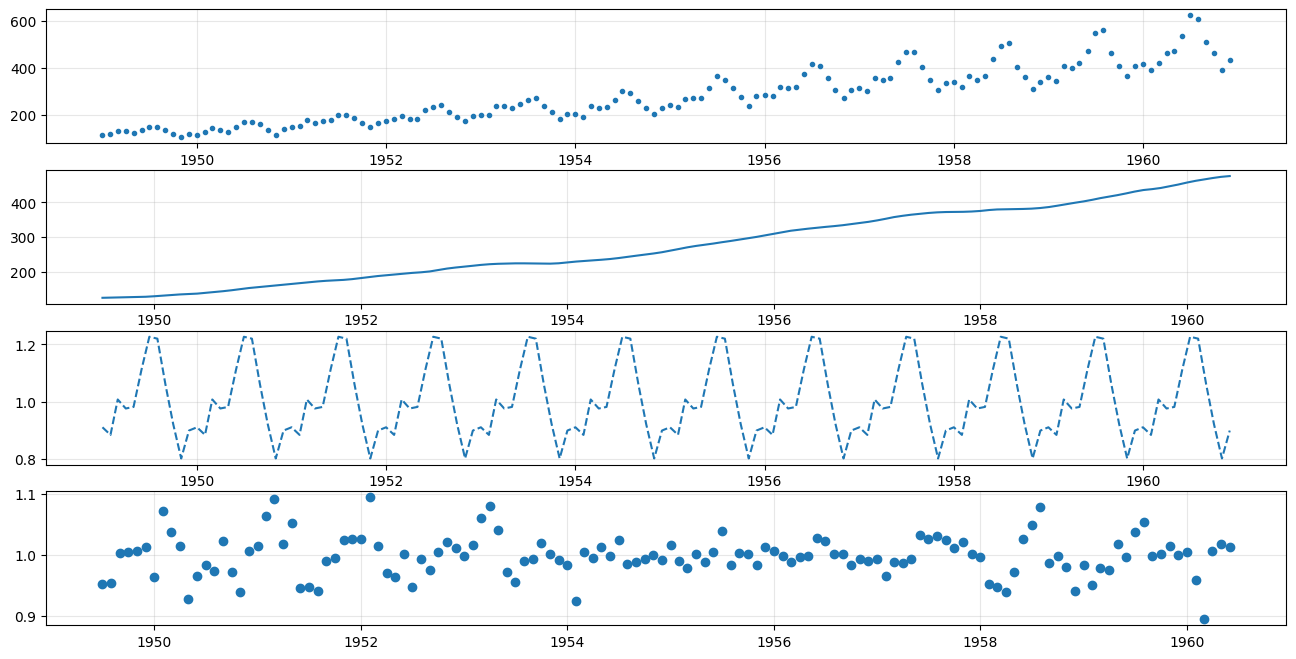

In [28]:
# We will use subplot for this tasks 

plt.figure(figsize=(16,8))

plt.subplot(411)
plt.plot(df,".")

plt.subplot(412)
plt.plot(decomposed_df.trend,'-')

plt.subplot(413)
plt.plot(decomposed_df.seasonal,'--')

plt.subplot(414)
plt.plot(decomposed_df.resid,"o")

plt.show()

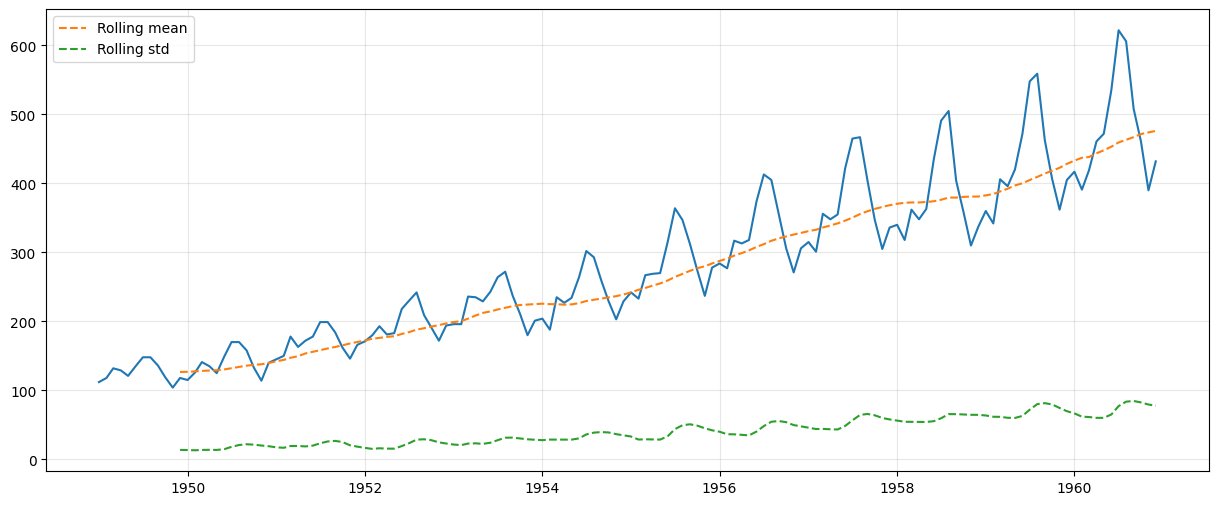

In [31]:
plt.figure(figsize=(15,6))

plt.plot(df,"-")
plt.plot(df['#Passengers'].rolling(window=12).mean(),"--",label="Rolling mean")
plt.plot(df['#Passengers'].rolling(window=12).std(),"--",label="Rolling std")

plt.legend()
plt.show()

In [32]:
# Hence this time seris is multiplicative and needs differencing or tranformation before forecasting using AR,MA,ARMA,ARIMA or SARIMA.

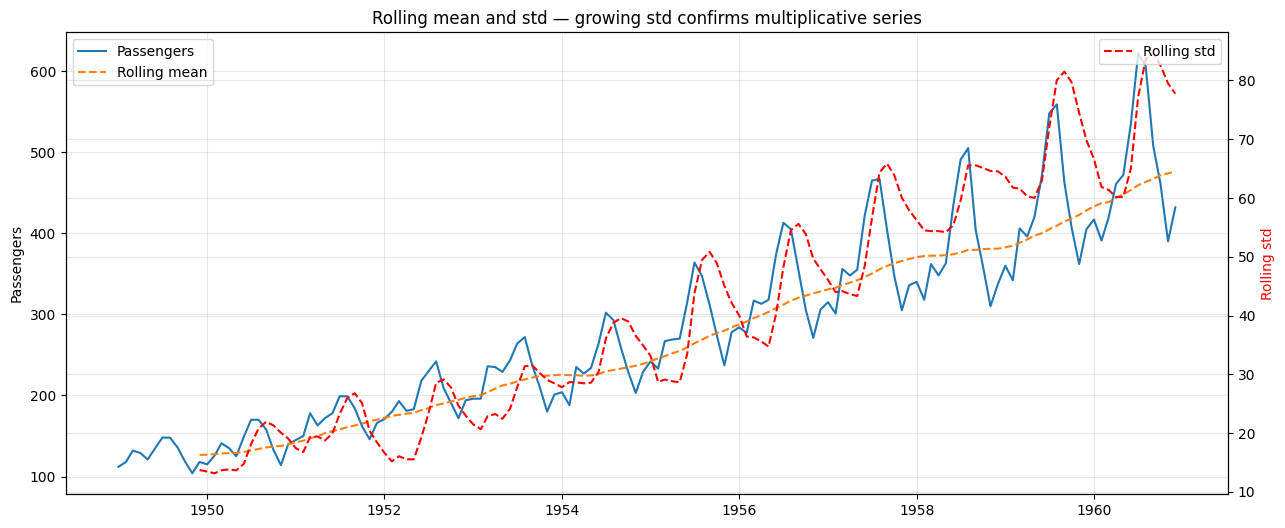

In [33]:
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(df, '-', label='Passengers')
ax1.plot(df['#Passengers'].rolling(12).mean(), '--', label='Rolling mean')
ax1.set_ylabel('Passengers')

ax2 = ax1.twinx()   # second y-axis on the right
ax2.plot(df['#Passengers'].rolling(12).std(), '--', color='red', label='Rolling std')
ax2.set_ylabel('Rolling std', color='red')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Rolling mean and std — growing std confirms multiplicative series')
plt.show()

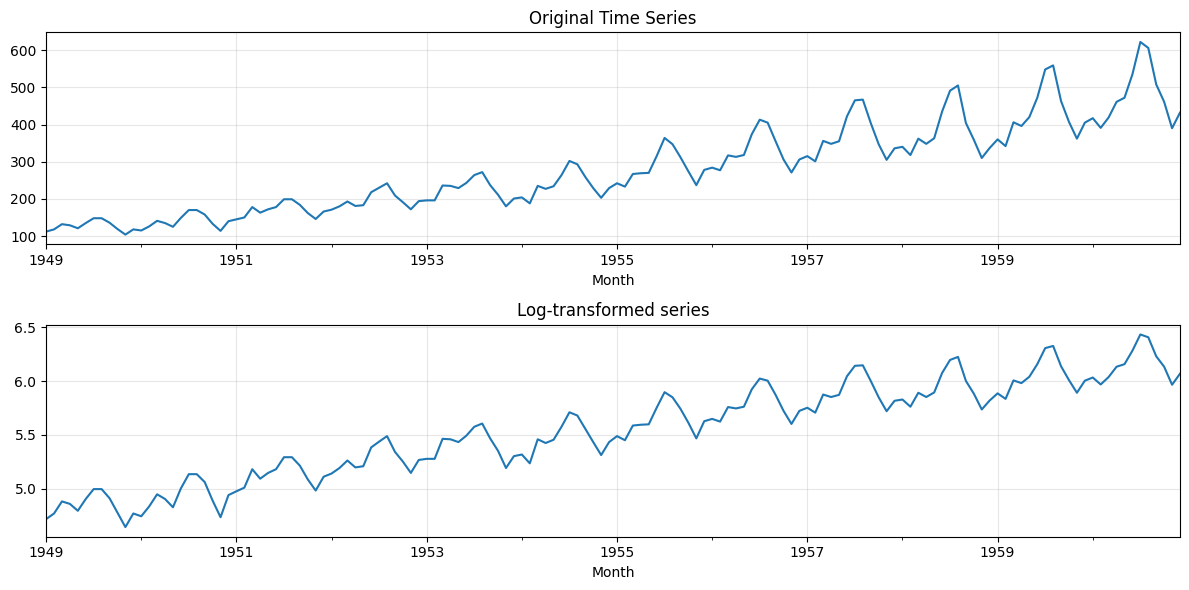

In [37]:
y = df['#Passengers']
y_log = np.log(y)

plt.figure(figsize=(12,6))

plt.subplot(211)
y.plot(title="Original Time Series")

plt.subplot(212)
y_log.plot(title='Log-transformed series')
plt.tight_layout()
plt.show()

In [38]:
# The trend peaks have become blunt but the trend still remains 

In [ ]:
# Now differencing this time seris for the first time 

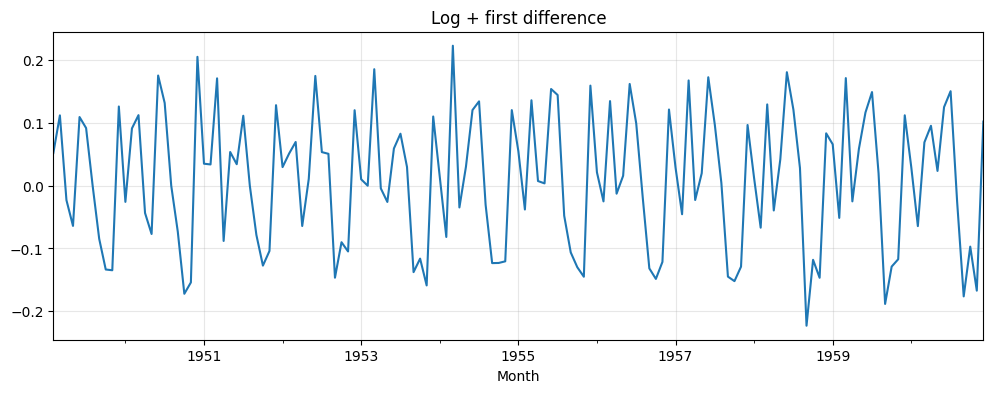

In [39]:
y_log_diff = y_log.diff().dropna()

y_log_diff.plot(title='Log + first difference')
plt.show()

In [43]:
# The trend seems to have been disappeared , now we will run the ADF test to confirm the significance of each stage of time seris data

In [44]:
from statsmodels.tsa.stattools import adfuller

for name, series in [('Original', y),
                     ('Log', y_log),
                     ('Log + diff', y_log_diff)]:
    result = adfuller(series.dropna())
    print(f"{name:15s} → ADF stat: {result[0]:.4f}   p-value: {result[1]:.5f}")

Original        → ADF stat: 0.8154   p-value: 0.99188
Log             → ADF stat: -1.7170   p-value: 0.42237
Log + diff      → ADF stat: -2.7171   p-value: 0.07112
